In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as pyplot
import seaborn as sns

In [3]:
df = pd.read_csv("wine_data.csv", usecols=[0,1,2], header=None)
df.columns = ['Class Label', 'Alcohol', 'Malic Acid']
df.sample(5)

,Class Label,Alcohol,Malic Acid
9,1,13.86,1.35
55,1,13.56,1.73
106,2,12.25,1.73
13,1,14.75,1.73
44,1,13.05,1.77


<Axes: xlabel='Malic Acid', ylabel='Density'>

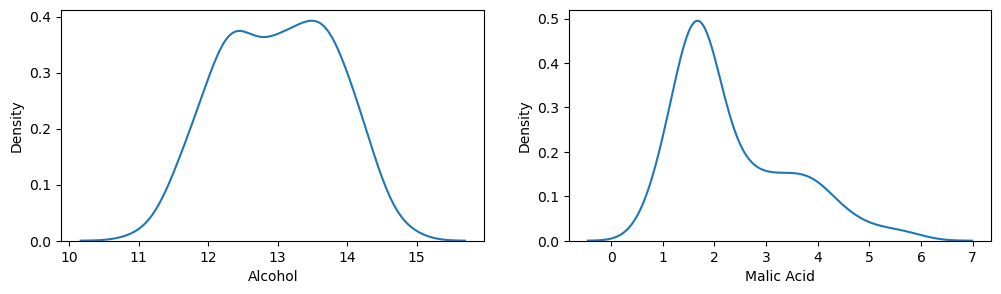

In [4]:
pyplot.figure(figsize=(12,3))
pyplot.subplot(1,2,1)
sns.kdeplot(x=df['Alcohol'])

pyplot.subplot(1,2,2)
sns.kdeplot(x=df['Malic Acid'])

<Axes: xlabel='Alcohol', ylabel='Malic Acid'>

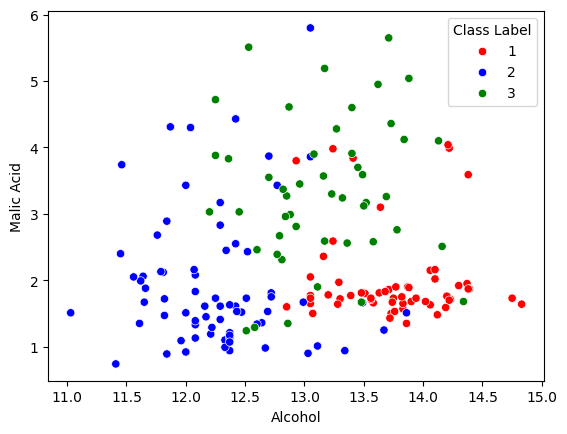

In [5]:
color_dict = {1:'red', 2:'blue', 3:'green'}
sns.scatterplot(x=df['Alcohol'], y=df['Malic Acid'], hue=df['Class Label'], palette=color_dict)    
# palette provides different color for hue to distinguish Class Label 1,2,3

<h2 style="color:red">Train Test Split</h2>

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:, 1:], df['Class Label'], test_size=0.3, random_state=0)

X_train.shape, X_test.shape

((124, 2), (54, 2))

<h2 style="color:red">MinMax Scaling</h2>

In [8]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
# Scales features to range [0, 1].
# Formula intuition:         Xi - Xmin
#                     z = ---------------
#                           Xmax - Xmin

# fit the scaler to the train set, it will learn the parameters
scaler.fit(X_train)

# transform train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)        # numpy array

In [9]:
#  convert numpy array Scaled data into pandas dataframe
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [10]:
np.round(X_train.describe(), decimals=2)

,Alcohol,Malic Acid
count,124.00,124.00
mean,12.98,2.38
std,0.80,1.14
min,11.03,0.89
25%,12.36,1.61
50%,13.04,1.88
75%,13.64,3.25
max,14.75,5.65


In [11]:
np.round(X_train_scaled.describe(), decimals=2)         
#  we can observe that *min = 0* and *max = 1*
# can predict about behavior of mean and std

,Alcohol,Malic Acid
count,124.00,124.00
mean,0.53,0.31
std,0.22,0.24
min,0.00,0.00
25%,0.36,0.15
50%,0.54,0.21
75%,0.70,0.50
max,1.00,1.00


<h2 style="color:red">Analysing Actual and Scaled Data</h2>

In [12]:
# Shape remains same, only scale changes.
#  in some cases, distribution shape may change

<Axes: title={'center': 'After Scaling'}, xlabel='Alcohol', ylabel='Malic Acid'>

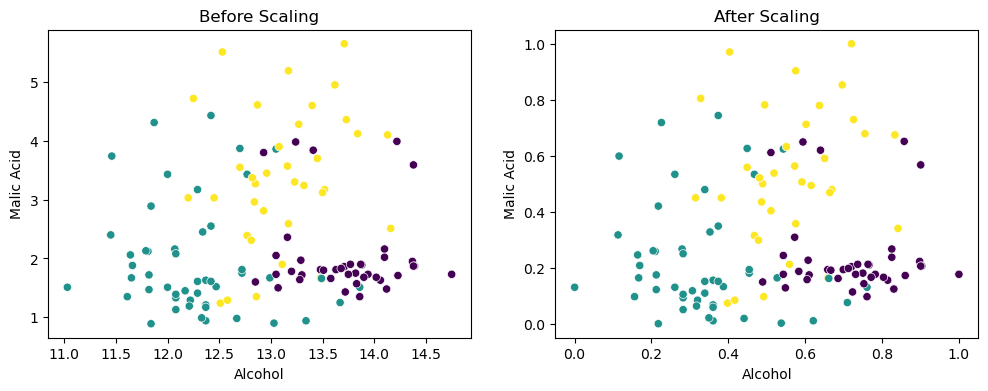

In [13]:
pyplot.figure(figsize=(12,4))
pyplot.subplot(1,2,1)
pyplot.title("Before Scaling")
sns.scatterplot(x=X_train['Alcohol'], y=X_train['Malic Acid'], c=y_train)         #  c stands for color.

pyplot.subplot(1,2,2)
pyplot.title("After Scaling")
sns.scatterplot(x=X_train_scaled['Alcohol'], y=X_train_scaled['Malic Acid'], c=y_train)

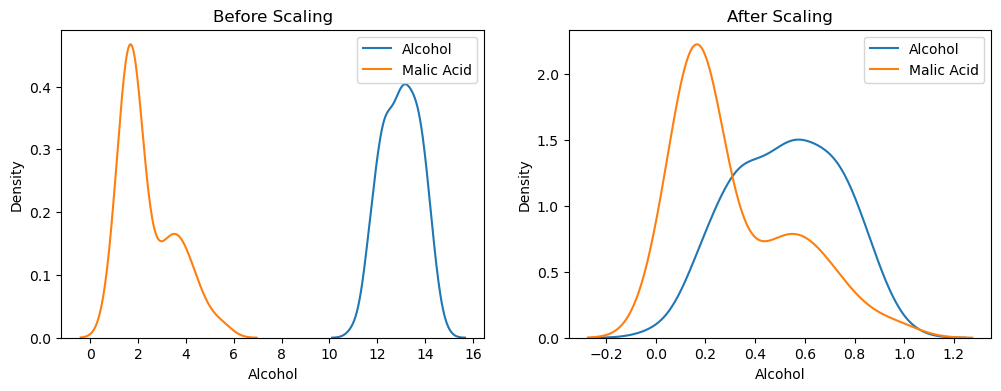

In [14]:
pyplot.figure(figsize=(12,4))
pyplot.subplot(1,2,1)
pyplot.title("Before Scaling")
sns.kdeplot(x=X_train['Alcohol'], label="Alcohol")       
sns.kdeplot(x=X_train['Malic Acid'], label="Malic Acid")      
pyplot.legend()

pyplot.subplot(1,2,2)
pyplot.title("After Scaling")
sns.kdeplot(x=X_train_scaled['Alcohol'], label="Alcohol")       
sns.kdeplot(x=X_train_scaled['Malic Acid'], label="Malic Acid")      
pyplot.legend()

<Axes: title={'center': 'After Scaling'}, xlabel='Alcohol', ylabel='Density'>

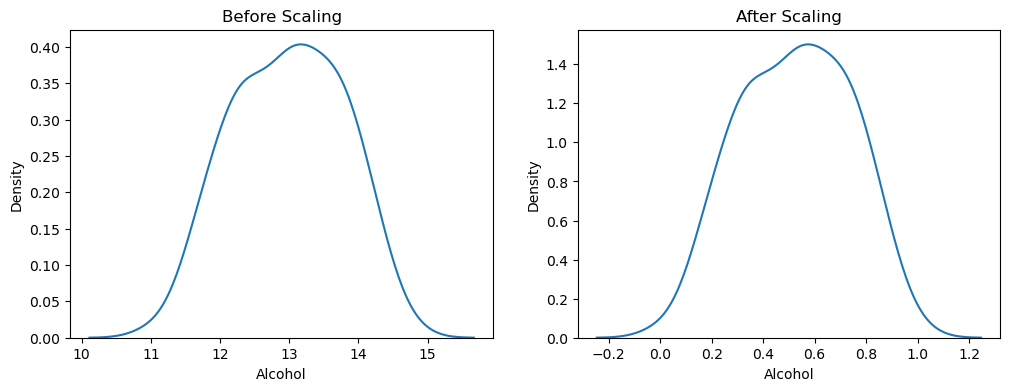

In [15]:
pyplot.figure(figsize=(12,4))
pyplot.subplot(1,2,1)
pyplot.title("Before Scaling")
sns.kdeplot(x=X_train['Alcohol'])       

pyplot.subplot(1,2,2)
pyplot.title("After Scaling")
sns.kdeplot(x=X_train_scaled['Alcohol'])       

<Axes: title={'center': 'After Scaling'}, xlabel='Malic Acid', ylabel='Density'>

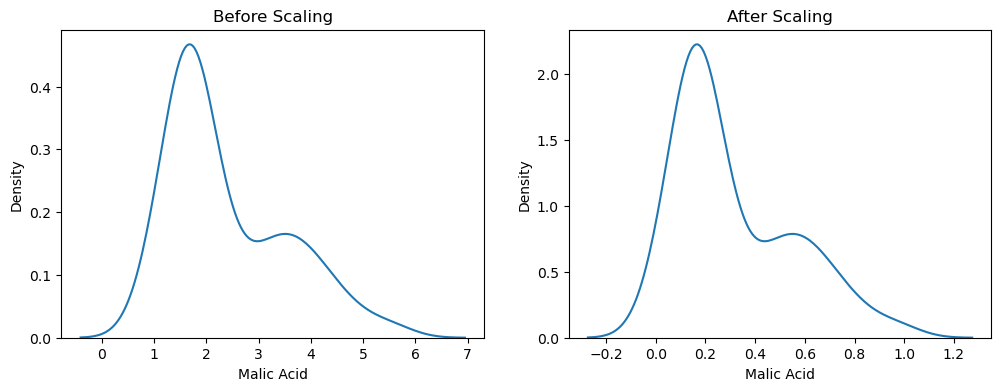

In [16]:
pyplot.figure(figsize=(12,4))
pyplot.subplot(1,2,1)
pyplot.title("Before Scaling")
sns.kdeplot(x=X_train['Malic Acid'])      

pyplot.subplot(1,2,2)
pyplot.title("After Scaling")
sns.kdeplot(x=X_train_scaled['Malic Acid'])      

<h2 style="color:red">MaxAbs Scaling</h2>

In [46]:
# MaxAbsScaling is useful for sparse data
# a dataset with a very large proportion of zero, null, or missing values. 
df.head()

,Class Label,Alcohol,Malic Acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59


In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df.iloc[:, 1:], df['Class Label'], test_size=0.3, random_state=0)

In [30]:
from sklearn.preprocessing import MaxAbsScaler

In [31]:
scaler = MaxAbsScaler()

scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [32]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [33]:
np.round(X_train.describe(), decimals=2)

,Alcohol,Malic Acid
count,124.00,124.00
mean,12.98,2.38
std,0.80,1.14
min,11.03,0.89
25%,12.36,1.61
50%,13.04,1.88
75%,13.64,3.25
max,14.75,5.65


In [34]:
np.round(X_train_scaled.describe(), decimals=2)

,Alcohol,Malic Acid
count,124.00,124.00
mean,0.88,0.42
std,0.05,0.20
min,0.75,0.16
25%,0.84,0.28
50%,0.88,0.33
75%,0.92,0.57
max,1.00,1.00


<h4 style="color:red">Logistic Regression</h4>

In [35]:
from sklearn.linear_model import LogisticRegression

In [38]:
lr = LogisticRegression()
lr_scaled = LogisticRegression()

In [47]:
# Model learns patterns from training data
lr.fit(X_train, y_train)
lr_scaled.fit(X_train_scaled, y_train)

LogisticRegression()

In [48]:
# Predicts labels for test data
y_pred = lr.predict(X_test)
y_pred_scaled = lr_scaled.predict(X_test_scaled)

In [43]:
from sklearn.metrics import accuracy_score

In [44]:
print("Actual : ", accuracy_score(y_pred, y_test))
print("Scaled : ", accuracy_score(y_pred_scaled, y_test))

Actual :  0.7592592592592593
Scaled :  0.5925925925925926


<h2 style="color:red">Robust Scaling</h2>

In [56]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df.iloc[:, 1:], df["Class Label"], test_size=0.3, random_state=0)

X_train.shape, X_test.shape

((124, 2), (54, 2))

In [58]:
from sklearn.preprocessing import RobustScaler

In [59]:
scaler = RobustScaler()

scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

<h4 style="color:red">Logistic Regression</h4>

In [60]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression() 
lr_scaled = LogisticRegression() 

In [62]:
lr.fit(X_train, y_train) 
lr_scaled.fit(X_train_scaled, y_train)

LogisticRegression()

In [63]:
y_pred = lr.predict(X_test)
y_pred_scaled = lr.predict(X_test_scaled)

In [64]:
from sklearn.metrics import accuracy_score

print("Actual : ", accuracy_score(y_pred, y_test))
print("Scaled : ", accuracy_score(y_pred_scaled, y_test))

Actual :  0.7592592592592593
Scaled :  0.4074074074074074


<h4 style="color:red">Decision tree</h4>

In [65]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt_scaled = DecisionTreeClassifier()

In [66]:
dt.fit(X_train, y_train)
dt_scaled.fit(X_train_scaled, y_train)

DecisionTreeClassifier()

In [67]:
y_pred = dt.predict(X_test)
y_pred_scaled = dt_scaled.predict(X_test_scaled)

In [68]:
from sklearn.metrics import accuracy_score

print("Actual : ", accuracy_score(y_pred, y_test))
print("Scaled : ", accuracy_score(y_pred_scaled, y_test))

Actual :  0.7962962962962963
Scaled :  0.7777777777777778


<h2 style="color:red">Effect of Outliers</h2>

In [18]:
# Min–Max normalization is highly sensitive to outliers.
#   ->  if an outlier becomes the min or max, it controls the scaling of all other points.

#  since we squeeze dataset in [0,1] range, outlier impact is also squeezed. 